Fundamentals of Deep Learning Models

# Lab 06-1: AlexNet for ImageNet Challenge (ILSVRC)
## Exercise: Image classification with AlexNet

This exercise implements the **AlexNet** architecture (Section 6.1) using the Keras Sequential API and trains it on the CIFAR-10 dataset as a practical substitute for the full ImageNet dataset.

AlexNet consists of five convolutional layers followed by three fully connected layers, corresponding to the architecture described in Figure 6.2. Key design features referenced from the text include:
- **ReLU activation** in all hidden layers (Section 6.1)
- **Overlapping max pooling** with 3×3 pool size and stride 2 (Section 6.1)
- **Dropout** ($p = 0.5$) in the fully connected layers to reduce overfitting (Section 6.1)
- **Softmax** output for $K$-class classification (Section 6.1)

**Note on modifications from the original AlexNet:**
- **Batch Normalization** is used in place of the original Local Response Normalization (LRN), as discussed in Section 6.1, which notes that substituting BatchNorm for LRN can lead to faster and more stable training.
- **He initialization** is applied to ReLU layers and **Glorot initialization** to the softmax output layer, following the initialization guidelines discussed in Section 4.4.
- The input images are resized to 227×227 to match the original AlexNet input specification, even though CIFAR-10 images are originally 32×32.

### Load libraries

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('TensorFlow Datasets version:', tfds.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# Check available GPU devices
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2
TensorFlow Datasets version: 4.9.9
Matplotlib version: 3.10.0
Num GPUs Available:  1


### Prepare datasets

This lab uses the **CIFAR-10** dataset (50,000 training + 10,000 test images, 32×32×3 pixels, 10 classes) as a practical substitute for ImageNet. An option to load **Imagenette** (a 10-class subset of ImageNet) is also provided.

The training set is split 80/20 into training and validation subsets.

In [2]:
dataset = 'cifar10'

if dataset == 'cifar10':
    # CIFAR-10: 50,000 training + 10,000 test images, 32x32x3, 10 classes
    (ds_train, ds_test, ds_val), ds_info = tfds.load(
        'cifar10', split=['train[:80%]', 'test', 'train[80%:]'],
        batch_size=None, shuffle_files=True, as_supervised=True,
        with_info=True)
elif dataset == 'imagenette':
    # Imagenette: 10-class subset of ImageNet (320px version)
    (ds_train, ds_test, ds_val), ds_info = tfds.load(
        'imagenette/320px-v2', split=['train', 'validation[:50%]', 'validation[50%:]'],
        batch_size=None, shuffle_files=True, as_supervised=True,
        with_info=True)
else:
    print('Dataset Error')

print(ds_info.features)
print(ds_info.splits)
print(ds_info.splits['train'].num_examples)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.7E4COC_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.7E4COC_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
FeaturesDict({
    'id': Text(shape=(), dtype=string),
    'image': Image(shape=(32, 32, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
})
{Split('train'): <SplitInfo num_examples=50000, num_shards=1>, Split('test'): <SplitInfo num_examples=10000, num_shards=1>}
50000


In [3]:
n_channels = ds_info.features['image'].shape[-1]

if dataset == 'imagenette':
    classes = ['tench', 'English springer', 'cassette player', 'chain saw',
               'church', 'French horn', 'garbage truck', 'gas pump',
               'golf ball', 'parachute']
else:
    classes = ds_info.features['label'].names
n_classes = ds_info.features['label'].num_classes

n_train = len(ds_train)
n_test = len(ds_test)
n_val = len(ds_val)

print(n_train, n_test, n_val)

40000 10000 10000


### Show a sample image

Image dimension: (32, 32, 3) , label: 1


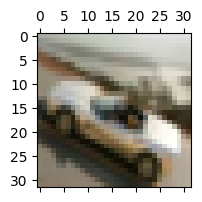

The picture is automobile


In [4]:
idx = np.random.randint(n_train - 1)

for element in ds_train.skip(idx).take(1):
    image, label = element

print('Image dimension:', image.shape, ', label:', label.numpy())

dimage = tf.reshape(image, image.shape)
plt.figure(figsize=(2, 2))
plt.matshow(dimage, 0)
plt.show()
print('The picture is', classes[label])

### Building input data pipelines

Images are normalized to $[0, 1]$ and resized to 227×227 to match the AlexNet input specification (Section 6.1, Figure 6.2). Labels are one-hot encoded for the softmax output layer.

In [5]:
def tfds_4_NET(image, label):
    # Normalize pixel values to [0, 1] and resize to 227x227 (AlexNet input size)
    image = tf.image.resize((image / 255), [227, 227], method='bilinear')
    # One-hot encode labels for categorical cross-entropy loss
    label = tf.one_hot(label, n_classes)

    return image, label

In [6]:
n_batch = 64

# Build training pipeline: map, shuffle, batch
dataset = ds_train.map(tfds_4_NET, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(buffer_size=256).batch(batch_size=n_batch)

# Build validation pipeline
valiset = ds_val.map(tfds_4_NET, num_parallel_calls=tf.data.AUTOTUNE)
valiset = valiset.shuffle(buffer_size=256).batch(batch_size=n_batch)

# Build test pipeline
testset = ds_test.map(tfds_4_NET, num_parallel_calls=tf.data.AUTOTUNE)
testset = testset.shuffle(buffer_size=256).batch(batch_size=n_batch)

### Network definition of AlexNet with Keras Sequential API

Implement the AlexNet architecture as described in Section 6.1 and Figure 6.2. The network consists of:
- **5 convolutional layers**: 96 filters (11×11, stride 4) → 256 filters (5×5) → 384 (3×3) → 384 (3×3) → 256 (3×3)
- **3 fully connected layers**: 4096 → 4096 → $K$ classes (softmax)
- **Overlapping max pooling** (3×3, stride 2) after layers 1, 2, and 5
- **Batch Normalization** after layers 1, 2, and 5 (replacing LRN; see Section 6.1)
- **Dropout** ($p = 0.5$) after fully connected layers 6 and 7 (Section 6.1)

In [ ]:
# Model definition
AlexNet = keras.Sequential([

    ### START CODE HERE ###

    # Input: 227x227 RGB image (Section 6.1, Figure 6.2)
    keras.layers.InputLayer(),

    # Conv Layer 1: 96 filters, 11x11, stride 4, no padding (Section 6.1)
    keras.layers.Conv2D(),
    # BatchNorm replaces original LRN (Section 6.1)
    keras.layers....
    # Overlapping max pooling: 3x3, stride 2 (Section 6.1)
    keras.layers....

    # Conv Layer 2: 256 filters, 5x5, stride 1, same padding (Section 6.1)
    tf.keras.layers.Conv2D(),
    ...

    # Conv Layer 3 to 5: 384 filters, 3x3, stride 1, same padding (Section 6.1)
    ...

    # Flatten feature maps to 1D vector (Section 6.1: 6x6x256 = 9216)
    keras.layers.Flatten(),

    # FC Layer 6 to 7: 4096 units, ReLU (Section 6.1, Figure 6.2)
    keras.layers.Dense(),
    ...

    # FC Layer 8 (output): K classes, softmax activation (Section 6.1)
    keras.layers.Dense()

    ### END CODE HERE ###
])

AlexNet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,324,746 (222.49 MB)

 Trainable params: 58,323,530 (222.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

### Training the model

The model is compiled with **categorical cross-entropy** loss and trained using the **Adam** optimizer. The original AlexNet paper used SGD with momentum and learning-rate scheduling (Section 6.1); Adam is used here for convenience.

In [8]:
opt = keras.optimizers.Adam(learning_rate=0.001)
AlexNet.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['acc'])

In [9]:
n_epochs = 10

results = AlexNet.fit(dataset, epochs=n_epochs, batch_size=n_batch,
                      validation_data=valiset, validation_batch_size=n_batch,
                      verbose=1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 110ms/step - acc: 0.2942 - loss: 2.6041 - val_acc: 0.2705 - val_loss: 2.0190
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 103ms/step - acc: 0.3950 - loss: 1.6861 - val_acc: 0.2728 - val_loss: 2.0648
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - acc: 0.4718 - loss: 1.4947 - val_acc: 0.2943 - val_loss: 2.0401
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 103ms/step - acc: 0.5356 - loss: 1.3317 - val_acc: 0.4716 - val_loss: 1.4993
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - acc: 0.5790 - loss: 1.2205 - val_acc: 0.5584 - val_loss: 1.2743
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 102ms/step - acc: 0.6109 - loss: 1.1405 - val_acc: 0.6396 - val_loss: 1.1198
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - acc: 0.6543 - loss: 1.0135 - val_acc: 0.6134 - val_loss: 1.1270
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - acc: 0.6819 - loss: 0.9415 - val_acc: 0.6719 - val_loss: 0.9732
Epoch 9/10
625/625 ━━━━━━━━━━━━━

### Saving trained parameters

In [10]:
# Uncomment to save the trained model
# AlexNet.save('AlexNet.h5')

### Plot convergence graph

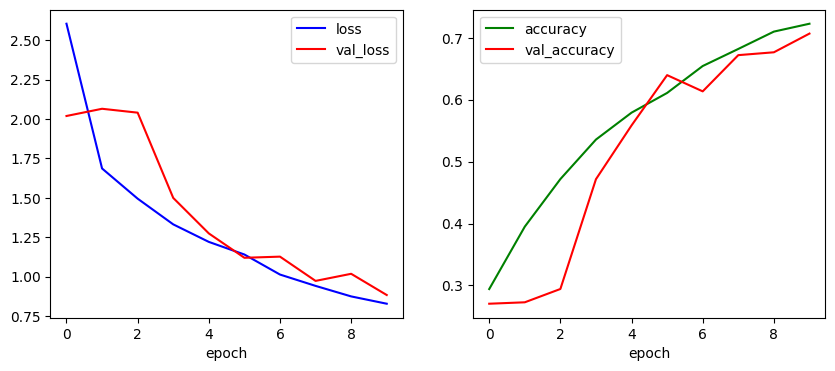

In [11]:
# Plot training/validation loss and accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(results.history['loss'], 'b-', label='loss')
plt.plot(results.history['val_loss'], 'r-', label='val_loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results.history['acc'], 'g-', label='accuracy')
plt.plot(results.history['val_acc'], 'r-', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()

plt.show()

### Evaluate model performance

In [12]:
# Evaluate on the test set
# If GPU memory is insufficient, uncomment the following:
# import gc
# gc.collect()
# keras.backend.clear_session()

AlexNet.evaluate(testset)

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - acc: 0.7065 - loss: 0.8821


[0.8820783495903015, 0.7064999938011169]

### Test model with a random sample

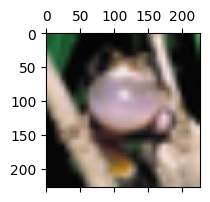

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
My prediction is frog
Actual image is  frog


In [13]:
idx = np.random.randint(n_test - 1)

for element in ds_test.skip(idx).take(1):
    img, lbl = element
    X_test, y_test = tfds_4_NET(img, lbl)

# Add batch dimension for prediction
X_test = tf.expand_dims(X_test, axis=0)

# Display the test image
dimage = np.array(X_test[0])
plt.figure(figsize=(2, 2))
plt.matshow(dimage, 0)
plt.show()

# Predict and compare
outt_4 = AlexNet.predict(X_test)
p_pred = np.argmax(outt_4, axis=-1)

print('My prediction is ' + classes[p_pred[0]])
print('Actual image is  ' + classes[tf.argmax(y_test, -1)])

(c) 2026 S. W. Lee